### Defnitions
Varmepumpe besparelse = 50-80%

Andrel til oppvarming = 67%

Varmepunpe utslipp = 7.87 tonn #daikin heat pump

etterisolering 20-30%

562kg  ca for en enebolig 


Antal boliger oppgradert per år. 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

houses = pd.read_csv('data/bygningsbestand_2022.csv').set_index('byggeaar')
houses


,antall,varmepumpe,etterisolert,energi
byggeaar,,,,
1900,79505.0,0.0,0.0,22480.199109
1901,2407.0,0.0,0.0,22480.199109
1902,2407.0,0.0,0.0,22480.199109
1903,2407.0,0.0,0.0,22480.199109
1904,2407.0,0.0,0.0,22480.199109
...,...,...,...,...
2096,0.0,0.0,0.0,0.000000
2097,0.0,0.0,0.0,0.000000
2098,0.0,0.0,0.0,0.000000


### Data

**Kilde:** SSB tabell 06266 (antall eneboliger per byggeår) og 10576 (gjennomsnittlig energiforbruk per husholdning per byggeår). Energiforbruk er skalert med faktor 22848/17518 fra tabell 10573 for å korrigere fra gjennomsnittlig bolig til enebolig. Alle energibærere (elektrisitet, ved, fjernvarme) er summert til én `energi`-kolonne — alt behandles som elektrisk.

### Boligbestand

- **Eksisterende boliger (≤2022):** Antall og energiprofil fra CSV, gruppert per byggeår.
- **Nye boliger (2023–2100):** `new_houses` boliger legges til hvert år med energiforbruk `new_house_energi` (kan variere over tid, f.eks. lineært fallende).
- **Riving:** Hvert år rives en andel `demoliton_rate` av alle eksisterende boliger uavhengig av alder.

### Scenarioer

Tre scenarioer sammenlignes — alle bruker samme oppgraderingsrate (`retrofit_rate`) og kun boliger bygget **før `retrofit_max_year`** oppgraderes:

1. **Baseline** — ingen oppgraderinger, energiforbruk forblir konstant per kohort
2. **Varmepumpe** — reduserer oppvarmingsdelen av energiforbruket med `varmepumpe_besparelse`
3. **Etterisolering** — reduserer oppvarmingsdelen med `etterisolering_besparelse`

### Energiberegning

For hvert år beregnes totalt energiforbruk som:

$$E_{yr} = \sum_{byggeår} antall_{byggeår,yr} \times energi_{byggeår} \times faktor_{byggeår,yr}$$

der reduksjonsfaktoren for oppgradering er:

$$faktor = oppvarming\\_andel \times (1 - andel_{oppgradert} \times besparelse) + (1 - oppvarming\\_andel)$$

Kun oppvarmingsdelen (67%) påvirkes — resten (belysning, varmtvann, etc.) forblir uendret.

### Utslipp

$$utslipp_{yr} = E_{yr} \times karbonintensitet_{yr}$$

Karbonintensiteten synker lineært fra 0.25 til 0.05 kgCO₂/kWh (2022–2100).

### Byggeutslipp

Hver oppgradering har en engangskostnad i embodied CO₂:
- Varmepumpe: `co2_per_varmepumpe` tCO₂ (f.eks. Daikin)
- Etterisolering: `co2_per_etterisolering` tCO₂

Disse legges til som årlig utslipp basert på antall *nye* oppgraderinger det året.

### Antakelser og begrensninger

- Alle energibærere behandles som elektrisk — ingen differensiering av utslippsfaktor
- `new_house_energi` er en antakelse, ikke basert på SSB-data for fremtidige byggeforskrifter
- Oppgraderingsraten er uniform for alle kohorter ≤ `retrofit_max_year`
- Varmepumpe og etterisolering modelleres separat (ikke kombinert)
- Rivningsraten er konstant og aldersuavhengig

In [16]:
# Projection
projection_years = np.arange(2022, 2101)
demoliton_rate   = 0.002
new_houses       = 5000


new_house_energi = pd.Series(
    np.linspace(18000,8000,len(projection_years[1:])), 
    index=projection_years[1:]  # kWh per new house
)

# Carbon intensity (kgCO₂/kWh) — all electric
carbon_intensity = pd.Series(
    np.linspace(0.250, 0.050, len(projection_years)),
    index=projection_years,
)

# Retrofit scenario
retrofit_rate             = 0.02   # same rate for both heat pump and insulation
retrofit_max_year         = 1989   # only upgrade houses built up to this year
varmepumpe_besparelse     = 0.50   # heat pump reduces heating energy by 50%
etterisolering_besparelse = 0.25   # insulation reduces heating energy by 25%
oppvarming_andel          = 0.67   # fraction of energy used for heating
co2_per_varmepumpe        = 7.87   # tCO₂ per heat pump
co2_per_etterisolering    = 0.56   # tCO₂ per insulation job


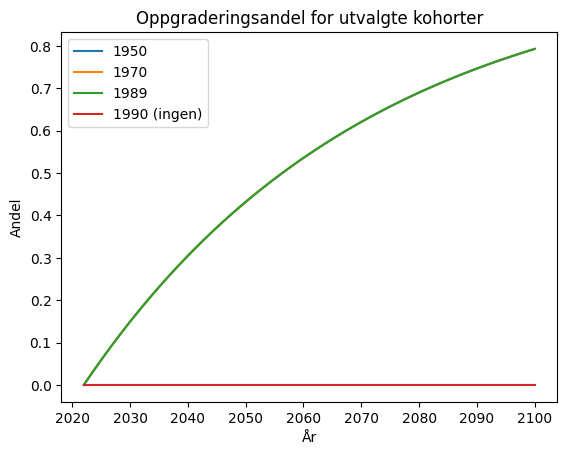

In [17]:
# House stock: antall per byggeår over tid
house_stock = pd.DataFrame(0.0, index=houses.index, columns=projection_years)
house_stock.loc[:2022, 2022] = houses['antall']

# Set energy profile for new houses (post-2022)
houses.loc[2023:, 'energi'] = new_house_energi

for yr in projection_years[1:]:
    house_stock.loc[:, yr] = house_stock.loc[:, yr - 1] * (1 - demoliton_rate)
    house_stock.loc[yr, yr] = new_houses

# Oppgraderingsandel per byggeår over tid (0.0–1.0)
# Kun boliger bygget før retrofit_max_year oppgraderes
retrofit_andel = pd.DataFrame(0.0, index=houses.index, columns=projection_years)

for yr in projection_years[1:]:
    prev = retrofit_andel.loc[:, yr - 1]
    retrofit_andel.loc[:, yr] = prev.copy()
    retrofit_andel.loc[:retrofit_max_year, yr] = prev.loc[:retrofit_max_year] + (1 - prev.loc[:retrofit_max_year]) * retrofit_rate

plt.plot(projection_years, retrofit_andel.loc[1950], label='1950')
plt.plot(projection_years, retrofit_andel.loc[1970], label='1970')
plt.plot(projection_years, retrofit_andel.loc[retrofit_max_year], label=f'{retrofit_max_year}')
plt.plot(projection_years, retrofit_andel.loc[retrofit_max_year + 1], label=f'{retrofit_max_year + 1} (ingen)')
plt.title('Oppgraderingsandel for utvalgte kohorter')
plt.ylabel('Andel')
plt.xlabel('År')
plt.legend()
plt.show()


In [18]:
# Three scenarios: baseline, only heat pump, only insulation
energy_baseline  = pd.Series(0.0, index=projection_years)
energy_vp        = pd.Series(0.0, index=projection_years)
energy_iso       = pd.Series(0.0, index=projection_years)
utslipp_bygg_vp  = pd.Series(0.0, index=projection_years)
utslipp_bygg_iso = pd.Series(0.0, index=projection_years)

prev_retrofit_total = 0.0

for yr in projection_years:
    stock = house_stock.loc[:, yr]
    andel = retrofit_andel.loc[:, yr]

    # Baseline — no upgrades
    energy_baseline.loc[yr] = stock @ houses['energi']

    # Heat pump only
    heating_factor_vp = 1 - andel * varmepumpe_besparelse
    factor_vp = oppvarming_andel * heating_factor_vp + (1 - oppvarming_andel)
    energy_vp.loc[yr] = stock @ (houses['energi'] * factor_vp)

    # Insulation only
    heating_factor_iso = 1 - andel * etterisolering_besparelse
    factor_iso = oppvarming_andel * heating_factor_iso + (1 - oppvarming_andel)
    energy_iso.loc[yr] = stock @ (houses['energi'] * factor_iso)

    # Embodied CO₂
    retrofit_now = (andel.loc[:retrofit_max_year] * stock.loc[:retrofit_max_year]).sum()
    new_retrofits = max(0, retrofit_now - prev_retrofit_total)
    utslipp_bygg_vp.loc[yr]  = new_retrofits * co2_per_varmepumpe
    utslipp_bygg_iso.loc[yr] = new_retrofits * co2_per_etterisolering
    prev_retrofit_total = retrofit_now

utslipp_baseline = energy_baseline * carbon_intensity
utslipp_vp       = energy_vp * carbon_intensity
utslipp_iso      = energy_iso * carbon_intensity


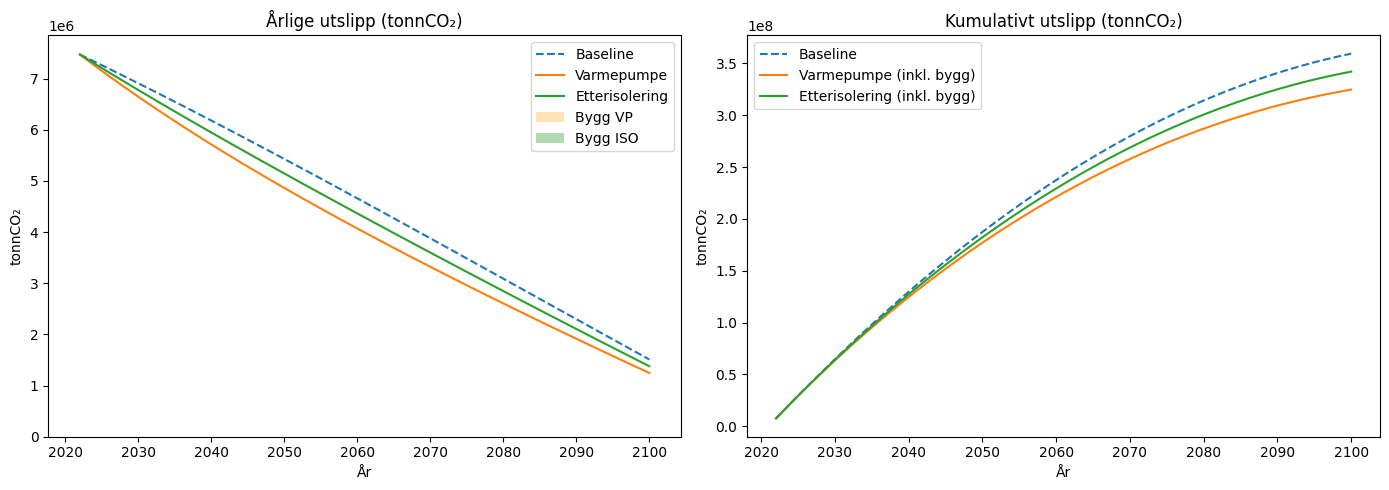

Spart med varmepumpe:     34,686,749 tonnCO₂
Spart med etterisolering: 17,345,637 tonnCO₂


In [19]:
# Comparison plots
vp_total  = utslipp_vp  + utslipp_bygg_vp
iso_total = utslipp_iso + utslipp_bygg_iso

baseline_cum = utslipp_baseline.cumsum() / 1e3
vp_cum       = vp_total.cumsum() / 1e3
iso_cum      = iso_total.cumsum() / 1e3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annual
axes[0].plot(projection_years, utslipp_baseline / 1e3, '--', label='Baseline')
axes[0].plot(projection_years, utslipp_vp / 1e3, label='Varmepumpe')
axes[0].plot(projection_years, utslipp_iso / 1e3, label='Etterisolering')
axes[0].bar(projection_years, utslipp_bygg_vp / 1e3, alpha=0.3, color='orange', label='Bygg VP')
axes[0].bar(projection_years, utslipp_bygg_iso / 1e3, alpha=0.3, color='green', label='Bygg ISO')
axes[0].set_title('Årlige utslipp (tonnCO₂)')
axes[0].set_ylabel('tonnCO₂')
axes[0].legend()

# Cumulative
axes[1].plot(projection_years, baseline_cum, '--', label='Baseline')
axes[1].plot(projection_years, vp_cum, label='Varmepumpe (inkl. bygg)')
axes[1].plot(projection_years, iso_cum, label='Etterisolering (inkl. bygg)')
axes[1].set_title('Kumulativt utslipp (tonnCO₂)')
axes[1].set_ylabel('tonnCO₂')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('År')

plt.tight_layout()
plt.show()

spart_vp  = baseline_cum.iloc[-1] - vp_cum.iloc[-1]
spart_iso = baseline_cum.iloc[-1] - iso_cum.iloc[-1]
print(f'Spart med varmepumpe:     {spart_vp:,.0f} tonnCO₂')
print(f'Spart med etterisolering: {spart_iso:,.0f} tonnCO₂')
